# Линал

Основой ноутбука является хендбук по спектральным методам

https://education.yandex.ru/handbook/math/article/spektralnie-metodi-i-matrichnie-razlozheniia

In [49]:
import torch
import matplotlib.pyplot as plt
import numpy as np


# Базовые преобразования

## Векторные преобразования

Базис понимается как матрица из 2 векторов-столбцов (базисных векторов)

In [50]:
basis = torch.Tensor([[1, 0], [0, 1]])
# A = torch.Tensor([[-1.8, 1.3], [0.4, 0.6]])
# A = torch.tensor([[3., 1.], [1., 3.]], dtype=torch.float32) 
A = torch.tensor([[1., 1.], [0., 1.]], dtype=torch.float32) # sheer matrix (матрица сдвига)
# A = torch.tensor([[0., 1.], [1., 0.]], dtype=torch.float32) # отражение по y=x
# A = torch.tensor([[0.5, 0.5], [0.5, 0.5]], dtype=torch.float32) # проекция на y=x (одно из собственных значений равно 0)
# A = torch.tensor([[0., -1.], [1.,  0.]], dtype=torch.float32) # поворот, собственные значения комплексиные
#A = torch.tensor([[1., 2.], [2., 4.01]], dtype=torch.float32) # хорошее приближение 1 сингулярным числом

In [51]:
def plot_vectors(vectors: torch.Tensor):
    plt.figure(figsize=(6, 6))

    for vec in vectors:
        plt.quiver(*vec, angles='xy', scale_units='xy', scale=1)
        
    plt.xlim(-5, 5)
    plt.ylim(-5, 5)
    plt.axhline(0, color='black', linewidth=0.5)
    plt.axvline(0, color='black', linewidth=0.5)
    plt.grid(True, linestyle='--')
    plt.show()

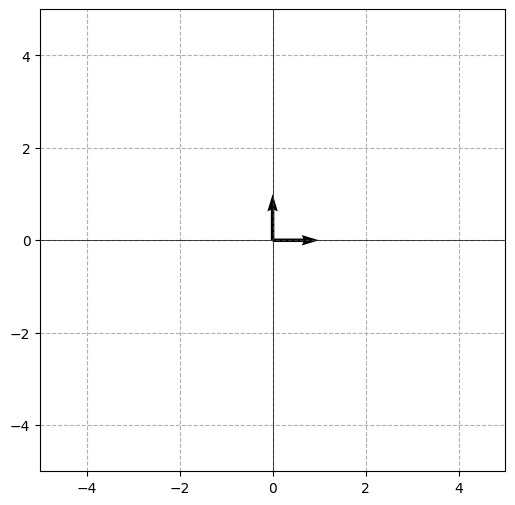

In [52]:
plot_vectors(basis)

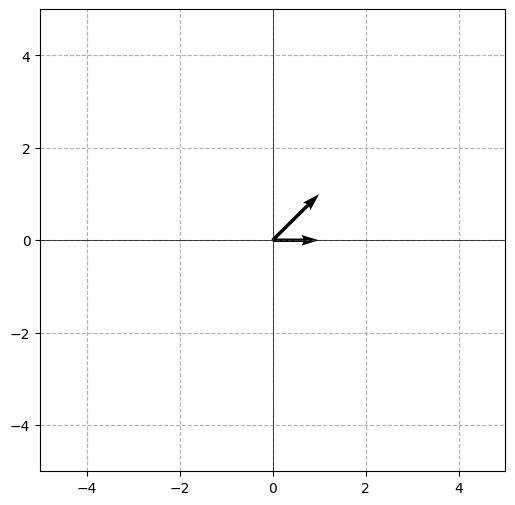

In [53]:
new_basis = A @ basis
plot_vectors(new_basis.T)

## Преобразования плоскости

In [54]:
dots_x = torch.arange(-5, 6, 1, dtype=torch.float32)
dots_y = torch.arange(-5, 6, 1, dtype=torch.float32)
dots = torch.cartesian_prod(dots_x, dots_y)

In [55]:
def plot_dots(dots: torch.Tensor, basis=torch.Tensor([[1, 0], [0, 1]]), draw_basis=False):
    plt.figure(figsize=(6, 6))
    plt.scatter(*dots.T)
        
    plt.xlim(-5, 5)
    plt.ylim(-5, 5)
    plt.axhline(0, color='black', linewidth=0.5)
    plt.axvline(0, color='black', linewidth=0.5)

    grid_range = np.arange(-10, 11, 1)

    v1 = basis.T[0]
    v2 = basis.T[1]
        
    for x in grid_range:
        start = x * v1 + grid_range[0] * v2
        end = x * v1 + grid_range[-1] * v2
        plt.plot([start[0], end[0]], [start[1], end[1]], color='lightgray', linestyle='--', linewidth=0.8)
    
    for y in grid_range:
        start = grid_range[0] * v1 + y * v2
        end = grid_range[-1] * v1 + y * v2
        plt.plot([start[0], end[0]], [start[1], end[1]], color='lightgray', linestyle='--', linewidth=0.8)

    if draw_basis:
        plt.quiver(0, 0, v1[0], v1[1], angles='xy', scale_units='xy', scale=1, color='blue')
        plt.quiver(0, 0, v2[0], v2[1], angles='xy', scale_units='xy', scale=1, color='red')
    
    plt.gca().set_aspect('equal')
    
    plt.show()

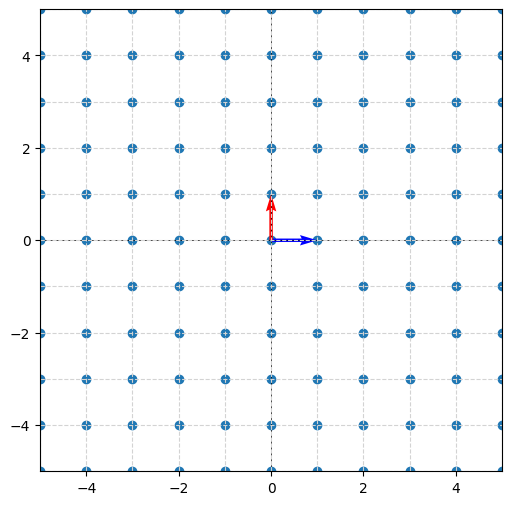

In [56]:
plot_dots(dots, basis, True)

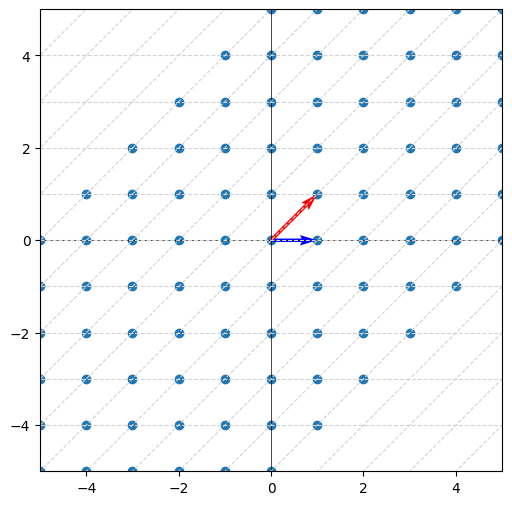

In [57]:
new_dots = (A @ dots.T).T
new_basis = (A @ basis)
plot_dots(new_dots, new_basis, True)

## Трансформация окружности

In [58]:
def circle_dots(r=1, n_dots=8):
    step = 2*torch.pi/n_dots
    theta = torch.arange(0, 2*torch.pi, step)
    x = torch.cos(theta) * r
    y = torch.sin(theta) * r
    return torch.stack([x, y]).T

In [59]:
circle = circle_dots(1, 16)

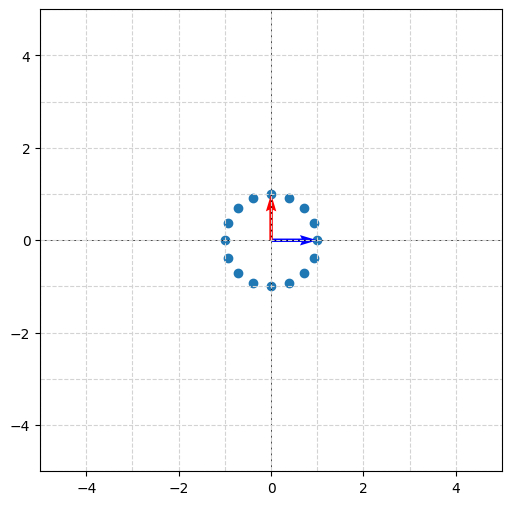

In [60]:
plot_dots(circle, basis, True)

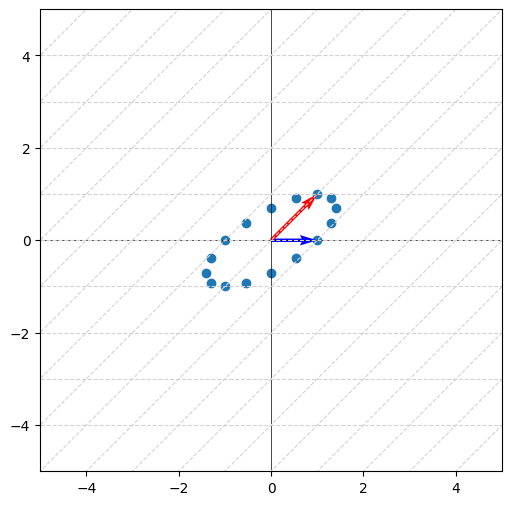

In [61]:
new_dots = (A @ circle.T).T
new_basis = (A @ basis)
plot_dots(new_dots, new_basis, True)

# Линал

## Матрица Грама

Матрица Грама $A^TA$ - матрица скалярных произведений по столбцам.

Свойства:

1. Симметрична $(A^TA)^T = A^T(A^T)^T = A^TA$. Следствие: по спектральной теореме $\exists$ ортонормированный базис из собственных векторов, все собственные значения вещественные
2. Положительная полуопределенность $x^T(A^TA)x = (Ax)^T(Ax) = {\vert Ax \vert}^2 \ge 0 $. Следствие: все собственные значения неотрицательны
3. $rank(A^TA) = rank(A)$

In [62]:
G = A.T @ A
G

tensor([[1., 1.],
        [1., 2.]])

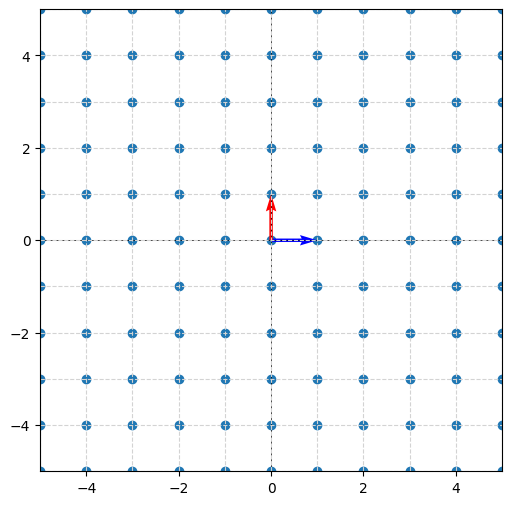

In [63]:
plot_dots(dots, basis, True) # дефолтное пространство

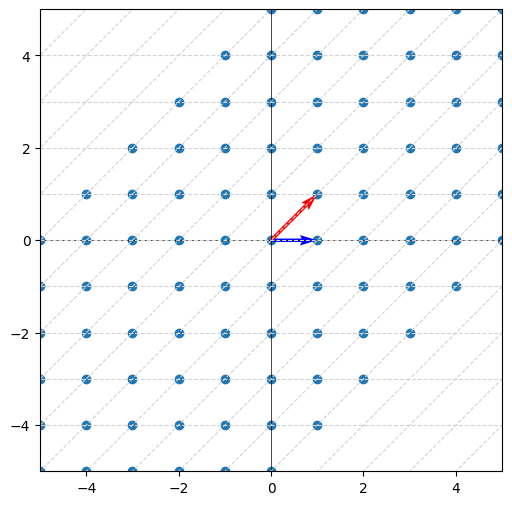

In [97]:
new_dots = (A @ dots.T).T
new_basis = (A @ basis)
plot_dots(new_dots, new_basis, True) # после A

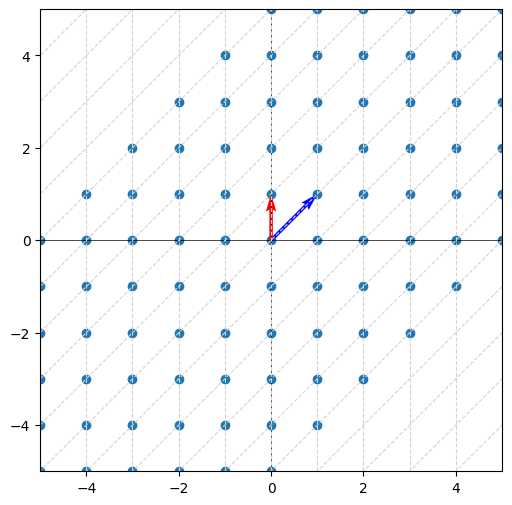

In [98]:
new_dots = (A.T @ dots.T).T
new_basis = (A.T @ basis)
plot_dots(new_dots, new_basis, True) # после A.T

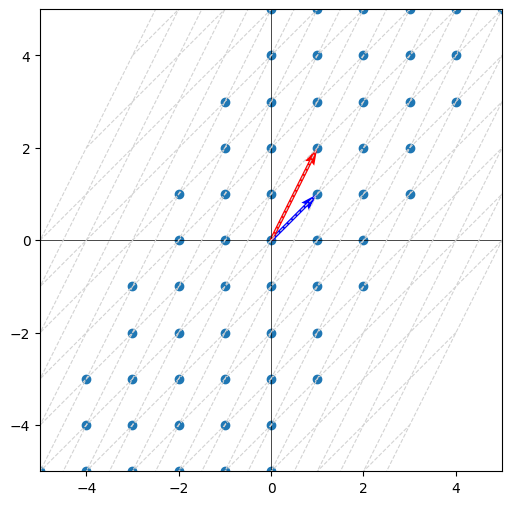

In [66]:
new_dots = (G @ dots.T).T
new_basis = (G @ basis)
plot_dots(new_dots, new_basis, True) # после матрицы Грама

## Ортогональные матрицы

$ A \in \mathbb{R}^{n \times n} $

$A^T = A^{-1}$

$A^TA = A^{-1}A = E$

Так как $A^TA$ - это матрица Грама, в которой содержатся попарные скалярные произведения всех векторов, можно утверждать:

1. $ \vert A_i \vert = 1$ - норма каждого столбца/строки равна 1. Cледует из определения нормы вектора $\vert v \vert = \langle v, v \rangle$ 
2. $ \langle A_i, A_j \rangle = 0, i \not = j $
3. $ \langle A_i, A_j \rangle = 1, i = j $ - следует из равенства матрицы Грама единичной.

Получается, что в ортогональной матрице по строкам/столбцам записан ортонормированный базис. При применении такой трансформации к пространству получим поворот/отражение без растяжения по осям
   

In [67]:
ortA = torch.tensor([[0, -1], [1,  0]], dtype=torch.float32)
invA = torch.linalg.inv(ortA)
print(ortA.T == invA)

tensor([[True, True],
        [True, True]])


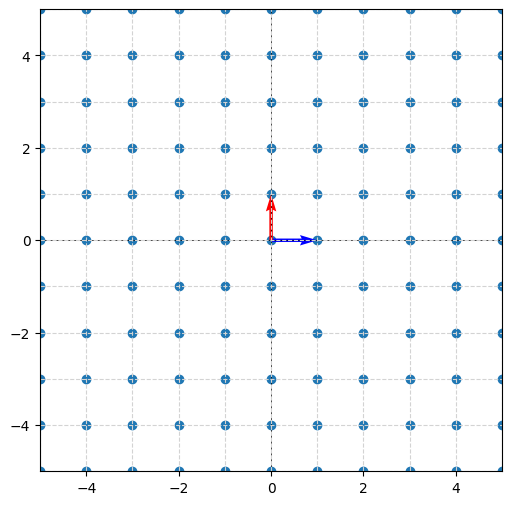

In [68]:
plot_dots(dots, basis, True)

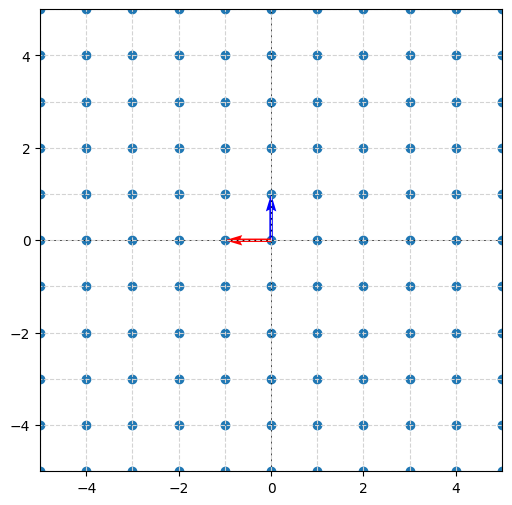

In [69]:
new_dots = (ortA @ dots.T).T
new_basis = (ortA @ basis)
plot_dots(new_dots, new_basis, True)

## Собственные значения (Eigen values)

Они же корни уравнения $\det \vert A - \lambda E \vert = 0$

Части про собственные и сингулярные вектора будут работать только с действительными собственными числами, тк комплексные значат что растяжения не происходит (например с матрицей поворота)

In [70]:
eigenvalues, eigenvectors = torch.linalg.eig(A)
eigenvectors = eigenvectors.to(dtype=torch.float32)
print(eigenvectors)
print(eigenvalues)

tensor([[ 1.0000e+00, -1.0000e+00],
        [ 0.0000e+00,  1.1921e-07]])
tensor([1.+0.j, 1.+0.j])


In [71]:
A @ eigenvectors.T[0] / eigenvectors.T[0]

tensor([1., nan])

In [72]:
def plot_dots_eigen(dots: torch.Tensor, eigen_vectors: torch.Tensor):

    eigen_vectors = eigen_vectors.T # так проще работать с индексами
    
    plt.figure(figsize=(6, 6))
    plt.scatter(*dots.T)
    plt.xlim(-5, 5)
    plt.ylim(-5, 5)
    plt.axhline(0, color='black', linewidth=0.5)
    plt.axvline(0, color='black', linewidth=0.5)
    
    for vec in eigen_vectors:
        t = torch.linspace(-10, 10, 100)
        x_line = t * vec[0]
        y_line = t * vec[1]
        plt.plot(x_line, y_line, color='lightgray', linestyle='--', linewidth=0.8)
    
    plt.quiver(*eigen_vectors[0], angles='xy', scale_units='xy', scale=1, color='red')
    plt.quiver(*eigen_vectors[1], angles='xy', scale_units='xy', scale=1, color='red')
    plt.gca().set_aspect('equal')
    plt.show()

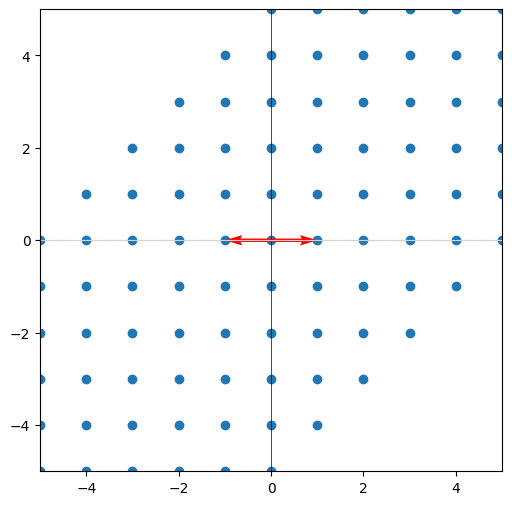

In [73]:
new_dots = (A @ dots.T).T
plot_dots_eigen(new_dots, eigenvectors)

In [74]:
def make_eigen_dots(eigen_vectors: torch.Tensor):

    eigen_vectors = eigen_vectors.T # так проще работать с индексами
    
    x = torch.arange(-5, 6, 1)
    outx = torch.Tensor([])
    outy = torch.Tensor([])
    for vec in eigen_vectors:
        k = vec[1] / vec[0]
        y = k * x
        outx = torch.concat([outx, x])
        outy = torch.concat([outy, y])

    return torch.stack([outx, outy]).T
        

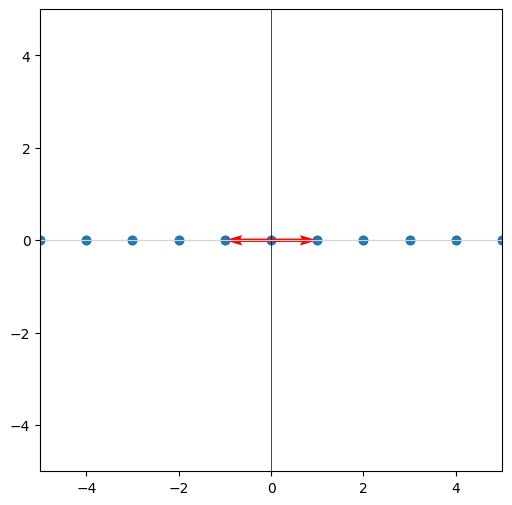

In [75]:
eigen_dots = make_eigen_dots(eigenvectors)
plot_dots_eigen(eigen_dots, eigenvectors)

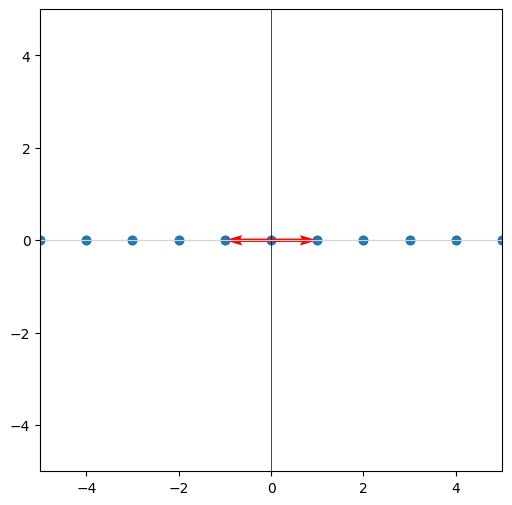

In [76]:
new_dots = (A @ eigen_dots.T).T
plot_dots_eigen(new_dots, eigenvectors)

## Сингулярные значения (Singular values)

In [77]:
eigenvalues, eigenvectors = torch.linalg.eig(A.T @ A)
right_singular_vectors = eigenvectors.to(dtype=torch.float32)
right_singular_values = torch.sqrt(eigenvalues.to(dtype=torch.float32))
print(right_singular_vectors)
print(right_singular_values)

tensor([[-0.8507, -0.5257],
        [ 0.5257, -0.8507]])
tensor([0.6180, 1.6180])


In [78]:
A.T @ A @ right_singular_vectors.T[0] / right_singular_vectors.T[0]

tensor([0.3820, 0.3820])

In [79]:
eigenvalues, eigenvectors = torch.linalg.eig(A @ A.T)
left_singular_vectors = eigenvectors.to(dtype=torch.float32)
left_singular_values = torch.sqrt(eigenvalues.to(dtype=torch.float32))
print(left_singular_vectors)
print(left_singular_values)

tensor([[ 0.8507, -0.5257],
        [ 0.5257,  0.8507]])
tensor([1.6180, 0.6180])


In [80]:
semiaxes_vectors = (left_singular_vectors * left_singular_values)
semiaxes_vectors

tensor([[ 1.3764, -0.3249],
        [ 0.8507,  0.5257]])

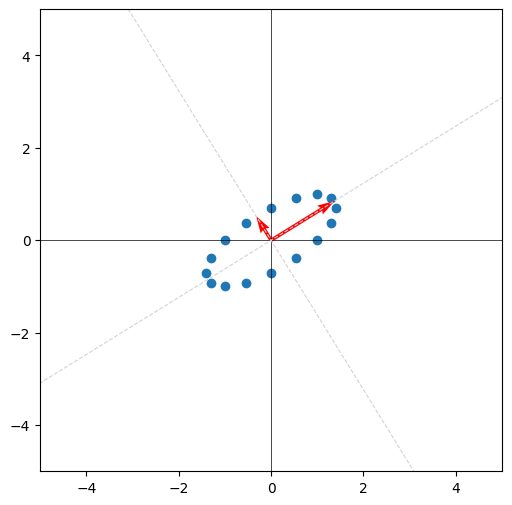

In [81]:
singular_dots = make_eigen_dots(semiaxes_vectors)
new_dots = (A @ circle.T).T
plot_dots_eigen(new_dots, semiaxes_vectors)

## SVD Сингулярное разложение (Singular Value Decomposition)

Работает для любой матрицы $\mathbb{R}^{m \times n}$, но рассматриваться будет только $\mathbb{R}^{2 \times 2}$

$A = U \Sigma V^T$, где

U - матрица из левых сингулярных векторов (собственные векторы матрицы $AA^T$)

$\Sigma$ - диагональная матрица сингулярных значений (сингулярные значения - собственные значения матрицы $A^TA$)

V - матрица из правых сингулярных векторов (собственные векторы матрицы $A^TA$)

In [82]:
A

tensor([[1., 1.],
        [0., 1.]])

In [83]:
sigma = torch.zeros((2, 2))
sorted_singular_values = sorted(right_singular_values, reverse=True)
for i in range(len(sorted_singular_values)):
    sigma[i][i] = sorted_singular_values[i]

sigma

tensor([[1.6180, 0.0000],
        [0.0000, 0.6180]])

In [84]:
left_singular_vectors @ sigma @ right_singular_vectors.T

tensor([[-1.0000,  1.0000],
        [-1.0000,  0.0000]])

### В данном случае результат будет совпадать не всегда, так как торч возвращает собственные векторы с произвольным знаком. Следующий способ работает гарантированно:

$Av_i = \sigma u_i$

$u_i = \frac{1}{\sigma} A v_i$

In [85]:
sorted_singular_values, ind = right_singular_values.sort(descending=True)
sorted_singular_values

tensor([1.6180, 0.6180])

In [86]:
right_singular_vectors

tensor([[-0.8507, -0.5257],
        [ 0.5257, -0.8507]])

In [87]:
right_singular_vectors = right_singular_vectors[:, ind] # чтобы сохранить порядок значение-вектор
right_singular_vectors

tensor([[-0.5257, -0.8507],
        [-0.8507,  0.5257]])

In [88]:
sigma = torch.diag(sorted_singular_values)
sigma

tensor([[1.6180, 0.0000],
        [0.0000, 0.6180]])

In [89]:
left_singular_vectors_signed = []
for i in range(len(sorted_singular_values)):
    left_singular_vectors_signed.append(1 / sorted_singular_values[i] * A @ right_singular_vectors[:, i])
left_singular_vectors = torch.stack(left_singular_vectors_signed).T
left_singular_vectors

tensor([[-0.8507, -0.5257],
        [-0.5257,  0.8507]])

In [90]:
left_singular_vectors @ sigma @ right_singular_vectors.T

tensor([[1.0000, 1.0000],
        [0.0000, 1.0000]])

Точное совпадение с оригинальной матрицей. Занулим меньшее значение в матрице $\Sigma$. Получим приближение оригинальной матрицы

In [91]:
sigma1 = sigma.clone()
sigma1[1][1] = 0
sigma1

tensor([[1.6180, 0.0000],
        [0.0000, 0.0000]])

In [92]:
left_singular_vectors @ sigma1 @ right_singular_vectors.T

tensor([[0.7236, 1.1708],
        [0.4472, 0.7236]])

## Визуализация SVD

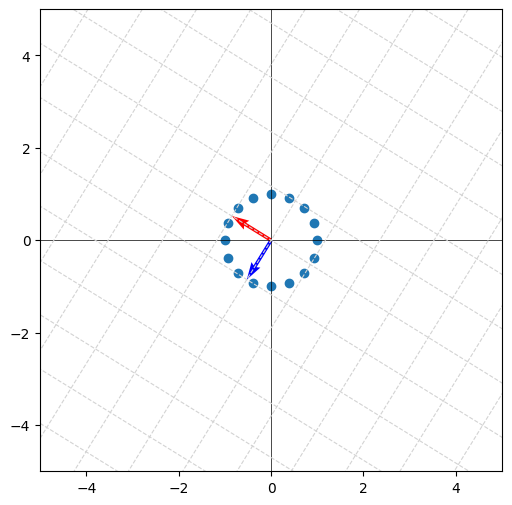

In [93]:
plot_dots(circle, right_singular_vectors, True)

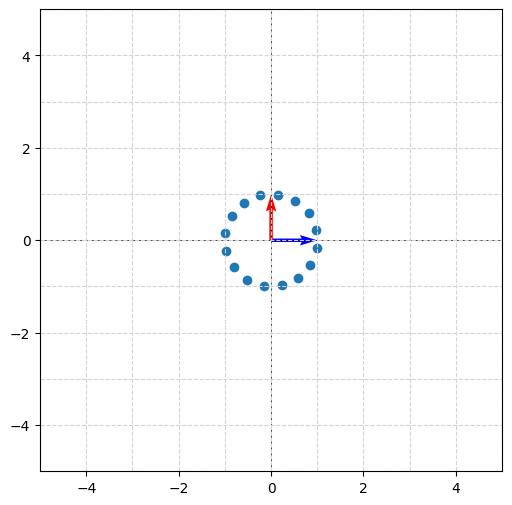

In [94]:
new_dots = (right_singular_vectors.T @ circle.T).T
new_basis = right_singular_vectors.T @ right_singular_vectors
plot_dots(new_dots, new_basis, True)

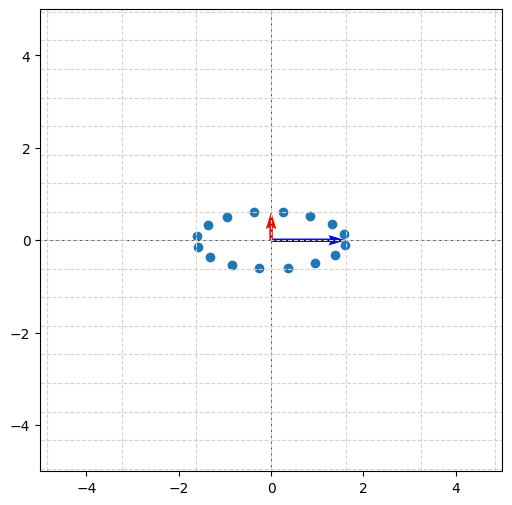

In [95]:
new_dots = (sigma @ right_singular_vectors.T @ circle.T).T
new_basis = sigma @ right_singular_vectors.T @ right_singular_vectors
plot_dots(new_dots, new_basis, True)

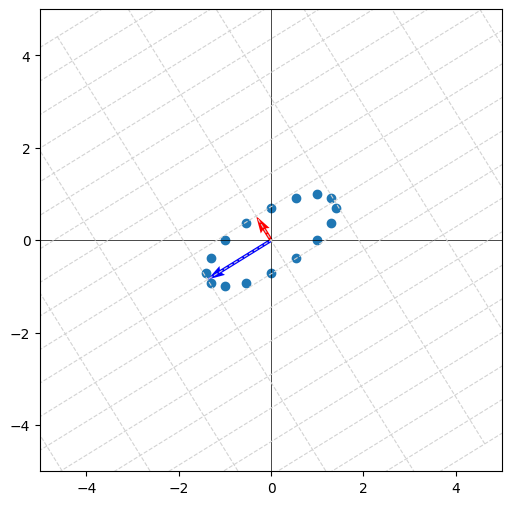

In [96]:
new_dots = (left_singular_vectors @ sigma @ right_singular_vectors.T @ circle.T).T
new_basis = left_singular_vectors @ sigma @ right_singular_vectors.T @ right_singular_vectors
plot_dots(new_dots, new_basis, True)

## Прикольные факты


Собственные значения определены в множестве $\mathbb{C}$ для действительной матрицы, действительные собственные значения определяют растяжение/стягивание по оси, комплексные - поворот + растяжение по оси в $\vert \lambda \vert$ раз. Комплексные собственные значения возникают только парами сопряженных комплексных чисел $\lambda_{1, 2} = ai \pm b$ и соответствуют векторам $e_{1, 2} = vi \pm u$, которые образуют в $\mathbb{R}^n$ двумерную вещественную плоскость. Если применить матрицу к векторам в этой плоскости, образы останутся в ней


В диагональной матрице собственные значения и сингулярные числа равны по модулю

$$ A \in \mathbb{R}^{n \times n} ;\;\; A_{ij} = 0 ;\; i \ne j $$

$$ \vert \lambda_i \vert = \sigma_i $$

Это легко проверить, в матрице $G = A^TA$ будет выполняться $G_{ij} = 0$, $G_{ii} = A_{ii}^2$. Тогда корни характеристического полинома $\lambda_i = A_{ii}$ и $\lambda^*_i = G_{ii} = A_{ii}^2$ для матрицы A и Грама соответственно. Сингулярные числа $\sigma_i = \sqrt{\lambda^*_i} = \sqrt{A_{ii}^2} = \vert A_{ii} \vert = \vert \lambda_i \vert$

